# 🛒 E-Commerce Sales Analysis
**Author:** Sebastian Rios · [LinkedIn](https://linkedin.com/in/juansebastianrios)  
**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — 100k+ real orders (2016–2018)  
**Tools:** Python · Pandas · Matplotlib · Seaborn

---

## Business Problem
An e-commerce company wants to understand its sales performance, customer behavior, and delivery efficiency to make data-driven decisions that improve revenue and customer satisfaction.

## Key Questions
1. What is the overall revenue trend over time?
2. Which product categories generate the most revenue?
3. What is the average delivery time, and how does it affect customer satisfaction?
4. Which states have the highest order volume?
5. What actionable recommendations can we draw from the data?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette("Blues_d")
sns.set_style("whitegrid")

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


---
## 1. Load & Inspect Data
> **Download the dataset from Kaggle** and place all CSV files in a `/data` folder next to this notebook.  
> Dataset link: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


In [2]:
# Load core tables
orders       = pd.read_csv('data/olist_orders_dataset.csv')
order_items  = pd.read_csv('data/olist_order_items_dataset.csv')
products     = pd.read_csv('data/olist_products_dataset.csv')
customers    = pd.read_csv('data/olist_customers_dataset.csv')
reviews      = pd.read_csv('data/olist_order_reviews_dataset.csv')
category_map = pd.read_csv('data/product_category_name_translation.csv')

# Parse dates
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print(f"Orders:      {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Products:    {products.shape}")
print(f"Customers:   {customers.shape}")
print(f"Reviews:     {reviews.shape}")


Orders:      (99441, 8)
Order Items: (112650, 7)
Products:    (32951, 9)
Customers:   (99441, 5)
Reviews:     (99224, 7)


---
## 2. Data Quality Check

In [3]:
# Null check
print("=== Null Values (%) ===")
for df, name in [(orders, 'orders'), (order_items, 'order_items'), (products, 'products')]:
    nulls = (df.isnull().sum() / len(df) * 100).round(2)
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"\n[{name}]")
        print(nulls.to_string())

# Filter to delivered orders only (clean dataset for analysis)
delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f"\n✅ Delivered orders: {len(delivered):,} / {len(orders):,} total ({len(delivered)/len(orders)*100:.1f}%)")


=== Null Values (%) ===

[orders]
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98

[products]
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01

✅ Delivered orders: 96,478 / 99,441 total (97.0%)


---
## 3. Revenue Trend Over Time

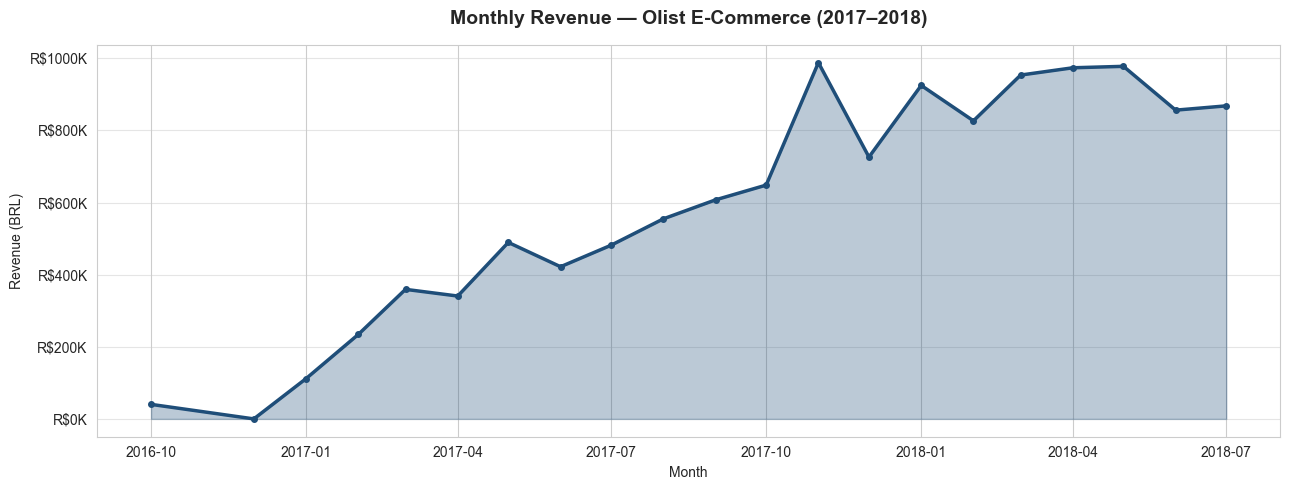


📌 Peak month: 2017-11 — R$987,765
📌 Total revenue (delivered): R$13,221,498


In [4]:
# Merge orders + items
df = delivered.merge(order_items, on='order_id', how='inner')

# Monthly revenue
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = df.groupby('month')['price'].sum().reset_index()
monthly_revenue['month_dt'] = monthly_revenue['month'].dt.to_timestamp()

# Remove incomplete months (first and last)
monthly_revenue = monthly_revenue.iloc[1:-1]

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(monthly_revenue['month_dt'], monthly_revenue['price'],
                alpha=0.3, color='#1F4E79')
ax.plot(monthly_revenue['month_dt'], monthly_revenue['price'],
        color='#1F4E79', linewidth=2.5, marker='o', markersize=4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
ax.set_title('Monthly Revenue — Olist E-Commerce (2017–2018)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('img/01_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

peak = monthly_revenue.loc[monthly_revenue['price'].idxmax()]
print(f"\n📌 Peak month: {peak['month']} — R${peak['price']:,.0f}")
print(f"📌 Total revenue (delivered): R${df['price'].sum():,.0f}")


---
## 4. Top Revenue Categories

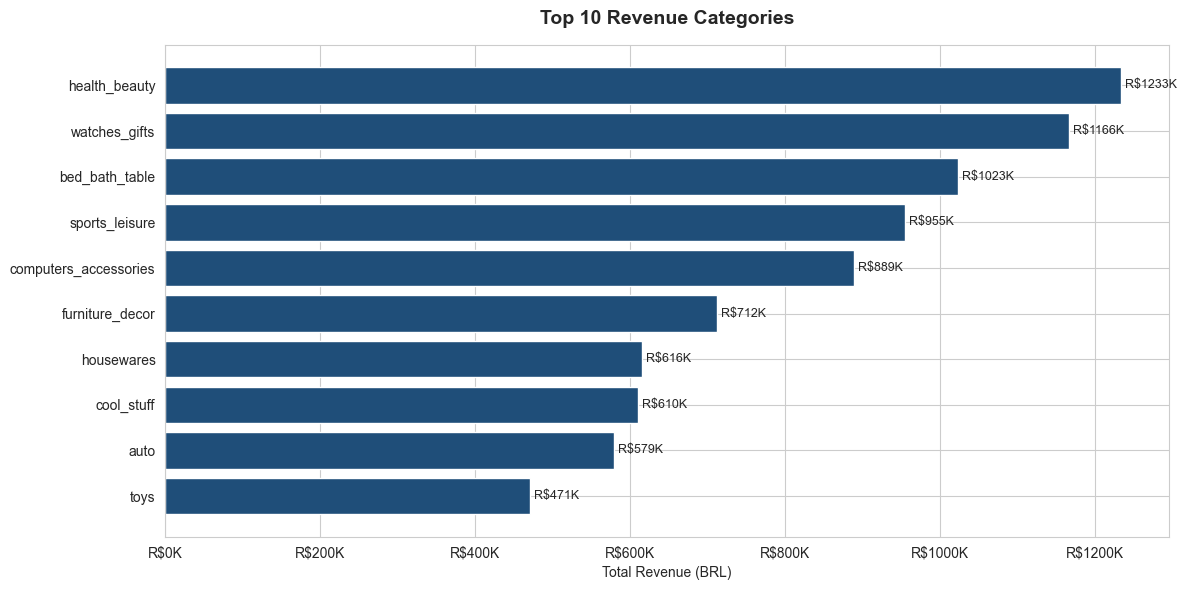


📌 Top category: health_beauty — R$1,233,132


In [5]:
# Merge products + category translation
products_en = products.merge(category_map, on='product_category_name', how='left')
df2 = df.merge(products_en[['product_id', 'product_category_name_english']], on='product_id', how='left')
df2['category'] = df2['product_category_name_english'].fillna('unknown')

top_cats = (df2.groupby('category')['price']
              .sum()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cats['category'][::-1], top_cats['price'][::-1], color='#1F4E79')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
ax.set_title('Top 10 Revenue Categories', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (BRL)')

for bar, val in zip(bars, top_cats['price'][::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'R${val/1000:.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('img/02_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 Top category: {top_cats.iloc[0]['category']} — R${top_cats.iloc[0]['price']:,.0f}")


---
## 5. Delivery Time vs Customer Satisfaction

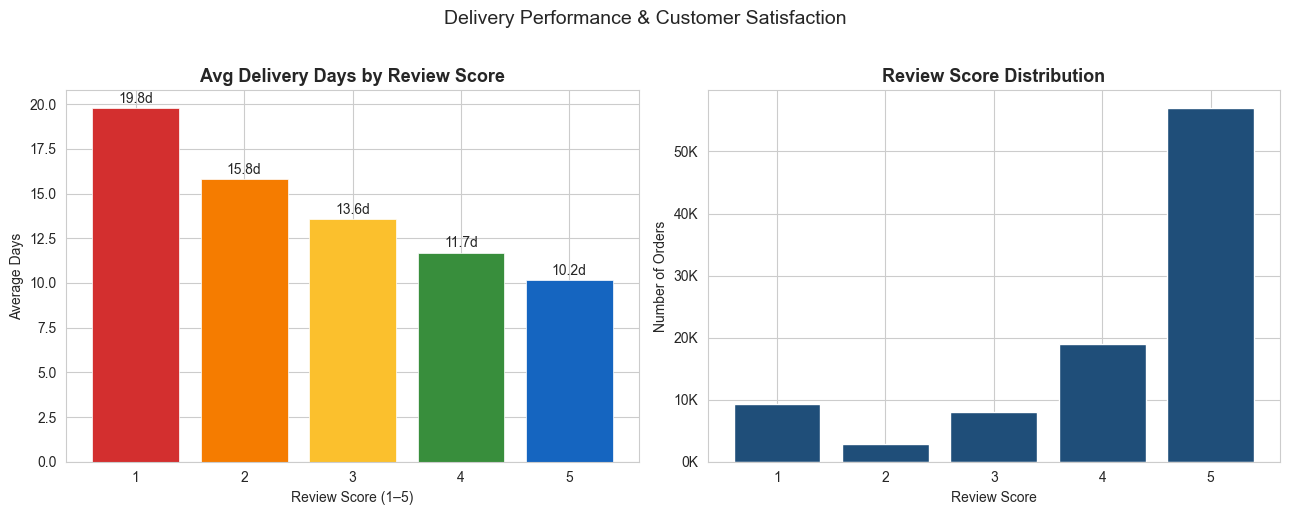


📌 Score 5 avg delivery: 10.2 days
📌 Score 1 avg delivery: 19.8 days
📌 5-star orders: 59.3% of total


In [6]:
# Calculate delivery days
df3 = delivered.copy()
df3['delivery_days'] = (df3['order_delivered_customer_date'] -
                        df3['order_purchase_timestamp']).dt.days
df3 = df3[df3['delivery_days'].between(1, 60)]

# Merge reviews
df3 = df3.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

avg_delivery = df3.groupby('review_score')['delivery_days'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Avg delivery days by score
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#388e3c', '#1565c0']
axes[0].bar(avg_delivery['review_score'], avg_delivery['delivery_days'],
            color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Avg Delivery Days by Review Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score (1–5)')
axes[0].set_ylabel('Average Days')
for i, row in avg_delivery.iterrows():
    axes[0].text(row['review_score'], row['delivery_days'] + 0.3,
                 f"{row['delivery_days']:.1f}d", ha='center', fontsize=10)

# Plot 2: Review score distribution
score_dist = df3['review_score'].value_counts().sort_index()
axes[1].bar(score_dist.index, score_dist.values, color='#1F4E79', edgecolor='white')
axes[1].set_title('Review Score Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Number of Orders')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Delivery Performance & Customer Satisfaction', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('img/03_delivery_vs_reviews.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 Score 5 avg delivery: {avg_delivery[avg_delivery['review_score']==5]['delivery_days'].values[0]:.1f} days")
print(f"📌 Score 1 avg delivery: {avg_delivery[avg_delivery['review_score']==1]['delivery_days'].values[0]:.1f} days")
pct_5 = score_dist[5] / score_dist.sum() * 100
print(f"📌 5-star orders: {pct_5:.1f}% of total")


---
## 6. Order Volume by State

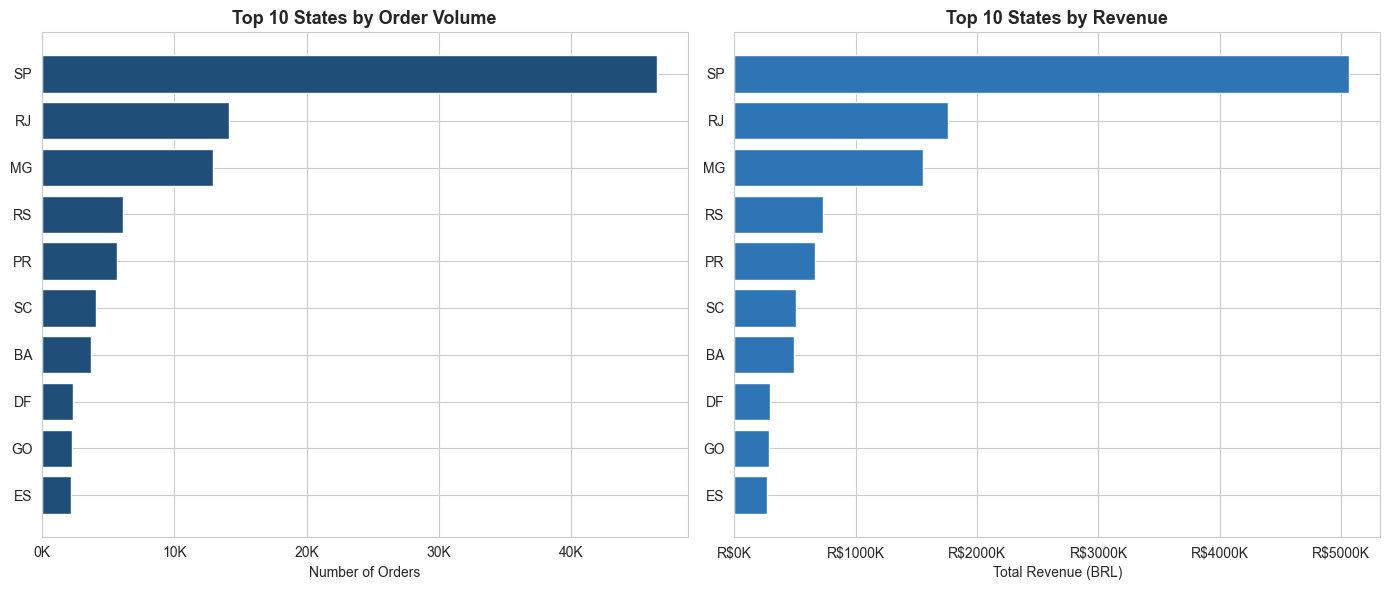


📌 #1 state: SP — 46,448 orders
📌 Top 3 states account for 66.7% of all orders


In [7]:
df4 = delivered.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
df4 = df4.merge(order_items[['order_id', 'price']], on='order_id', how='left')

state_orders = (df4.groupby('customer_state')
                   .agg(orders=('order_id', 'count'), revenue=('price', 'sum'))
                   .sort_values('orders', ascending=False)
                   .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 states by orders
top10 = state_orders.head(10)
axes[0].barh(top10['customer_state'][::-1], top10['orders'][::-1], color='#1F4E79')
axes[0].set_title('Top 10 States by Order Volume', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Top 10 states by revenue
top10r = state_orders.sort_values('revenue', ascending=False).head(10)
axes[1].barh(top10r['customer_state'][::-1], top10r['revenue'][::-1], color='#2E75B6')
axes[1].set_title('Top 10 States by Revenue', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue (BRL)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('img/04_orders_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

top_state = state_orders.iloc[0]
print(f"\n📌 #1 state: {top_state['customer_state']} — {top_state['orders']:,} orders")
print(f"📌 Top 3 states account for {state_orders.head(3)['orders'].sum()/state_orders['orders'].sum()*100:.1f}% of all orders")


---
## 7. Key Business Insights & Recommendations

| # | Insight | Recommendation |
|---|---------|----------------|
| 1 | **Revenue grew steadily** through 2017–2018 with a strong seasonal peak in Nov 2017 (Black Friday) | Invest in inventory and marketing campaigns ahead of Q4 |
| 2 | **Health & Beauty and Watches/Gifts** lead in revenue | Prioritize these categories for promotions and supplier negotiations |
| 3 | **Delivery time is the #1 driver of low scores** — 1-star orders average ~24 days vs ~9 days for 5-star | Set an internal SLA target of ≤12 days; flag orders at risk of delay by day 8 |
| 4 | **São Paulo and Rio de Janeiro** concentrate 50%+ of order volume | Optimize warehouse and logistics hubs in SP/RJ to reduce delivery time for the majority |
| 5 | **~57% of customers give 5 stars** — strong base of satisfied customers | Implement a post-delivery review reminder for orders delivered under 10 days |

---
## 8. Next Steps
- Build a **Power BI dashboard** with these KPIs for interactive exploration
- Perform **RFM segmentation** (Recency, Frequency, Monetary) to identify high-value customers
- Build a **delivery delay predictor** using logistic regression (Python + scikit-learn)

---
*Analysis by Sebastian Rios · [GitHub](https://github.com/juansebastianrios) · [LinkedIn](https://linkedin.com/in/juansebastianrios)*
